In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

np.random.seed(613)



In [2]:
tips = sns.load_dataset('tips')
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


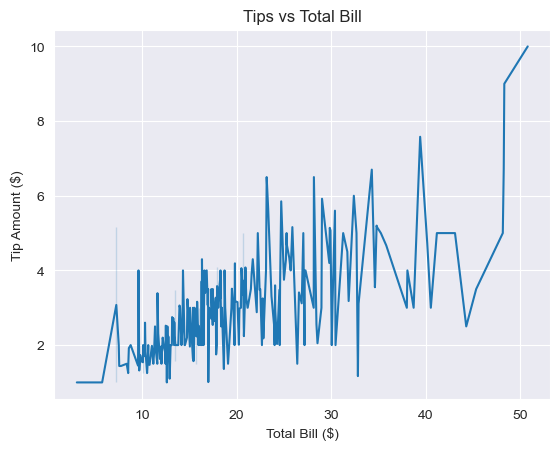

In [3]:
sns.set_style('darkgrid')

tipgraph = sns.lineplot(data=tips,
            x = 'total_bill',
            y = 'tip')

tipgraph.set(title = 'Tips vs Total Bill',
            xlabel = 'Total Bill ($)',
            ylabel = 'Tip Amount ($)')

plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

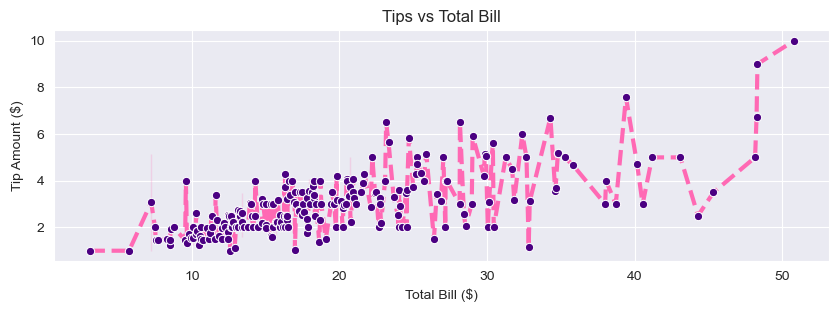

In [4]:
fig = plt.subplots(figsize=(10,3))

tipgraph = sns.lineplot(data = tips,
                        x = 'total_bill',
                        y = 'tip',
                        color = 'hotpink',
                        linestyle = '--',
                        linewidth = 3,
                        marker = 'o',
                        markerfacecolor = 'indigo')

tipgraph.set(title = 'Tips vs Total Bill',
            xlabel = 'Total Bill ($)',
            ylabel = 'Tip Amount ($)')

plt.show


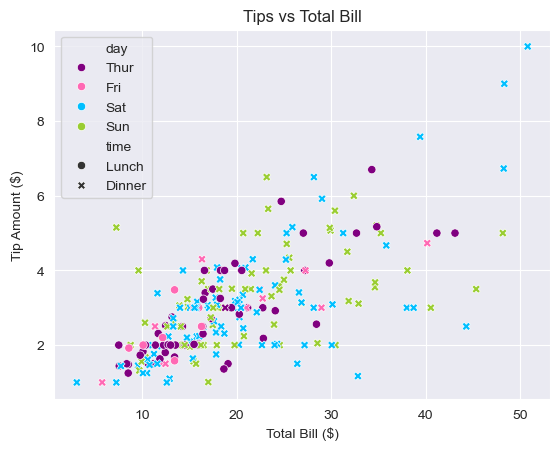

In [5]:
tipgraph = sns.scatterplot(data = tips,
                        x = 'total_bill',
                        y = 'tip',
                        style = 'time',
                        hue = 'day',
                        palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

tipgraph.set(title = 'Tips vs Total Bill',
            xlabel = 'Total Bill ($)',
            ylabel = 'Tip Amount ($)')

plt.show()

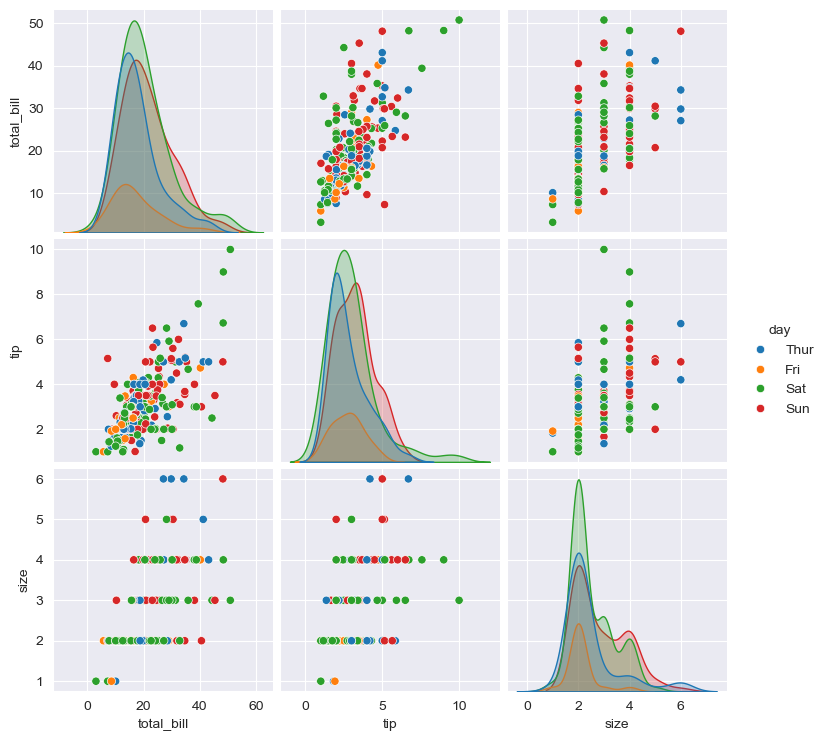

In [6]:
sns.pairplot(data = tips, hue = 'day')

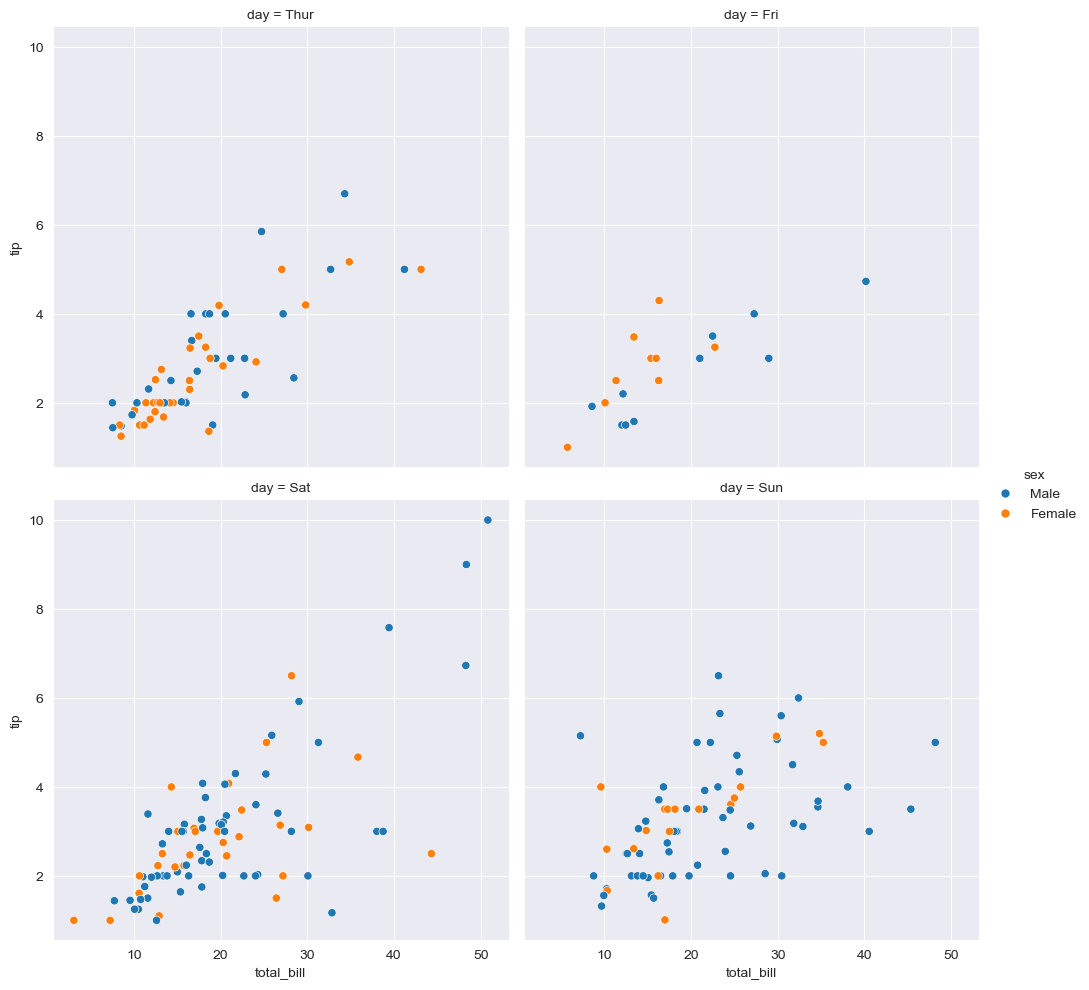

In [7]:
daysplot = sns.relplot(data = tips,
                        x = 'total_bill', #x variable should be amount of total bill
                        y = 'tip', # y variable should be the amount of tip
                        hue = 'sex', # color the data by sex
                        col = 'day', # one graph for each day
                        kind = 'scatter', # scatter plot
                        col_wrap = 2 ) # 2 graphs per row

daysplot

In [8]:
import plotly.graph_objects as go
import nbformat


x1 = np.array(['Luffy', 'Zoro', 'Nami', 'Usopp', 'Sanji'])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure()

graph.add_trace(go.Bar(x = x1, y = y1))

graph.update_layout(title = 'Pirate Scores',
                    xaxis_title = 'Pirates',
                    yaxis_title = 'Score')


graph.show()



In [9]:
graph = go.Figure()

graph.add_trace(go.Scatter(
    x=x1,
    y=y1,
    mode='markers',
    marker = dict(size = 15,
                  color = 'hotpink',
                  opacity = 1,
                  line = dict(width = 5, color ='purple'))
))

graph.update_layout(title = 'Interactive Pirate Plot',
                    xaxis_title = 'Pirates',
                    yaxis_title = 'Scores',
                    width = 500,
                    height = 500)

In [17]:
    from wordcloud import WordCloud

df = pd.read_csv('https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv',
                on_bad_lines='skip')

df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

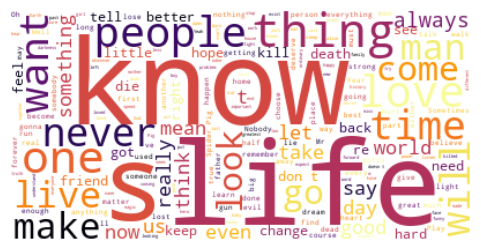

In [20]:
text = ''.join(each for each in df.quote)

wordcloud = WordCloud(background_color = 'white',
                      colormap = 'inferno',
                      random_state = 613).generate(text)

fig, ax = plt.subplots(figsize = (7,3))
ax.imshow(wordcloud, interpolation = 'bilinear')
ax.axis('off')

In [21]:
pip install matplotlib-venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=e68fcd504d3dbe92216ed1f3d0fc9e47d89d1f0bf5442e0343a8afe623dd9a78
  Stored in directory: /Users/ahilk/Library/Caches/pip/wheels/86/29/d8/0f3c5a37c967a34fb40aaabd414f92104d2ad5fb149c0114a1
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


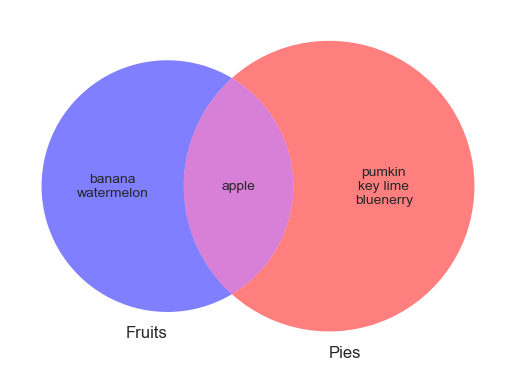

In [ ]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(['apple', 'banana', 'watermelon'])
B = set(['pumkin', 'bluenerry', 'apple', 'key lime'])

diagram = venn2([A,B],
                set_labels = ('Fruits', 'Pies'),
                set_colors = ('blue', 'red'),
                alpha = 0.5)

diagram.get_label_by_id('10').set_text('\n'.join(A-B)) #left
diagram.get_label_by_id('11').set_text('\n'.join(A & B)) #middle slice
diagram.get_label_by_id('01').set_text('\n'.join(B-A)) #right
